### Macro Data Generation

매크로 지표 $I_t$에 대해

$$I_{t+1} = I_{t} + \Delta E(I_{t+1}|\Omega_t) + u_t$$

$$u_t = \rho u_{t-1} + \varepsilon_t$$

을 따른다. 여기서 $E(I_{t+1}|\Omega_t)$은 $t$시점에서 가용가능한 모든 정보들로부터 추정된 $t+1$기의 매크로 지표 $I_{t+1}$에 대한 시장의 컨센서스이다.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
def simulate_stationary_macro_rate(
    n=120, r0=0.02, I0=100, mu_c=0.01, phi_c=0.8, gamma=0.5, sigma_c=0.005,
    phi=[0.5], theta=[0.3], omega=1e-6, alpha=0.1, beta=0.85, seed=None
):
    if seed is not None:
        np.random.seed(seed)

    q, p = len(theta), len(phi)
    r = np.zeros(n)           # 변화율 (stationary)
    delta_E = np.zeros(n)     # 컨센서스 변화율
    u = np.zeros(n)           # shock
    eps = np.zeros(n)
    sigma2 = np.ones(n) * omega / (1 - alpha - beta)
    I = np.zeros(n)
    I_hat = np.zeros(n)

    r[0] = r0
    delta_E[0] = mu_c
    I[0] = I0
    I_hat[0] = I0 * (1 + r0)

    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1]**2 + beta * sigma2[t - 1]
        sigma_t = np.sqrt(sigma2[t])
        eps_t = np.random.normal(0, sigma_t)
        eps[t] = eps_t

        # ARMA shock
        u_t = sum(phi[i] * u[t - i - 1] for i in range(min(p, t))) + \
              sum(theta[j] * eps[t - j - 1] for j in range(min(q, t))) + eps_t
        u[t] = u_t

        # forecast error = 이전 예측치와 실제 수익률 간 차이
        forecast_error = r[t - 1] - delta_E[t - 1]
        eta = np.random.normal(0, sigma_c)
        delta_E[t] = mu_c + phi_c * delta_E[t - 1] + gamma * forecast_error + eta

        # 수익률 = 컨센서스 + shock
        r[t] = delta_E[t] + u_t

        # 실제 값 & 예측 값
        I[t] = I[t - 1] * (1 + r[t])  # 누적 곱 방식
        I_hat[t] = I[t - 1] * (1 + delta_E[t])

    return pd.DataFrame({
        "Rate_r": r,
        "Consensus_E": delta_E,
        "Shock_u": u,
        "Shock_vol": np.sqrt(sigma2),
        "True_I": I,
        "I_hat": I_hat
    }, index=pd.date_range(start="1960-01-01", periods=n, freq="M"))

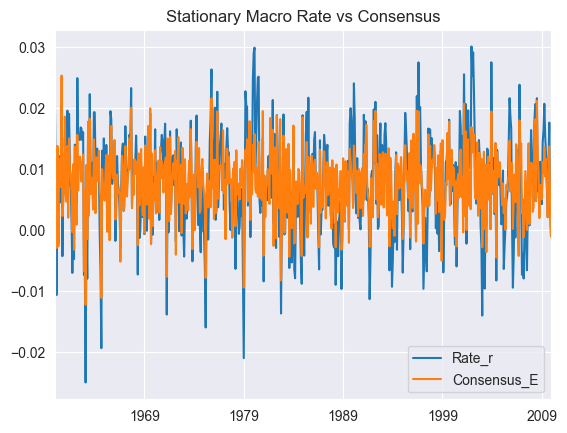

In [32]:
df = simulate_stationary_macro_rate(
    n=600, # 생성할 총 시계열의 길이
    r0=0.02, # 초기 변화율 지정
    I0=100, # 초기 시계열의 값
    mu_c=0.01, # 컨센서스의 평균 변화율
    phi_c=-0.3, # 컨센서스 변화의 자기상관도
    gamma=0.5, # 예측 오류에 대한 민감도
    sigma_c=0.005, # 시장 시대의 불확실성
    phi=[0.5], # 오차에 대한 AR 계수
    theta=[0.3], # 과거 오차에 대한 지연효과
    omega=1e-6, # GARCH모형에서의 변동성 상수항
    alpha=0.1, 
    beta=0.85, 
    seed=None
)
df[["Rate_r", "Consensus_E"]].plot(title="Stationary Macro Rate vs Consensus")
plt.show()

<Axes: >

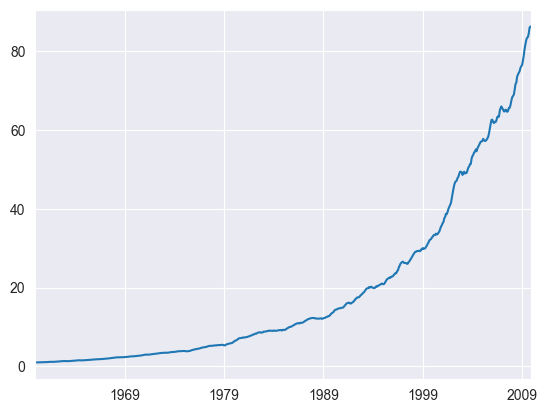

In [36]:
(1 + df['Rate_r']).cumprod().plot()

### 구조적 기대 기반 시계열 생성기의 필요성

거시경제 데이터를 기반으로 한 실증 분석 및 전략 테스트에서는, 
정량적 특성만 유사한 데이터를 넘어서, 
경제 구조와 기대 행동까지 반영된 해석 가능한 시계열 생성기가 요구된다.

기존의 데이터 생성 방식은 크게 두 가지 축으로 나뉜다.  첫째는 ARIMA, VAR 등 고전 시계열 모형을 기반으로 단순 반복/추세를 추정한 뒤 이를 기반으로 데이터 샘플을 생성하는 방식이다. 둘째는 최근 확산되고 있는 머신러닝 기반의 GAN (Generative Adversarial Networks)이나 RNN 기반 생성기처럼, 패턴 복제에 초점을 맞춘 블랙박스적 접근이다.  

하지만 이들 방식은 공통적으로 "예측은 가능하더라도, 경제적으로 해석이 가능한 구성 요소를 갖지 못한다"는 근본적인 한계를 지닌다.


#### 왜 '기대(expectation)'를 분리해야 하는가?

금융시장에서 자산 가격, 수익률, 또는 경제 지표의 변화는 단순히 noise나 계절성에 의해 움직이는 것이 아니라, 시장 참여자들의 기대와 그 기대의 변화에 의해 주도된다. 특히 중앙은행의 금리 결정, 정부의 재정정책 발표, 글로벌 이벤트 등은   실제 수치의 변화보다 그에 대한 '기대 변화'가 먼저 선반영되며, 이러한 기대감은 가격 변동성이나 전략적 포지셔닝의 핵심 원인이 된다.

예를 들어, 금리 인하가 발표되었을 때 시장은 이미 그 기대를 선반영했을 수 있으며, 실제 가격의 움직임은 "기대했던 것보다 덜 인하되었는가, 더 인하되었는가"에 따라 반응한다. 즉, '기대의 변화' 자체가 금융시장에서 가장 중요한 시계열 생성 동인 중 하나라는 것이다.

기존의 시계열 생성 모델들은 이러한 기대를 단순히 noise나 추세로 간주하거나, ARIMA/VAR 구조 내에 포함시키는 방식으로 처리해왔다. 그러나 이 방식은 현실 시장에서의 “기대의 조정 과정”, 즉 예측오차에 기반한 학습(adaptation)을 반영하지 못한다.

본 모델은 이러한 한계를 인식하고, 기대를 계절적 요소와 학습 기반 요소로 분리하여 시장 참여자가 정보에 반응하고 기대를 조정하는 과정을 시계열 생성 구조에 직접 반영하였다. 이 접근은 단순한 경제학적 해석이 아니라, 금융 전략 개발, backtest 환경 구축, 정책 이벤트 시나리오 설계 등 실전 투자 환경에서의 시계열 시뮬레이션 현실성을 높이기 위한 선택이다.

특히 전략 설계자는 특정 shock이나 정책 변화가 발생했을 때 시장 기대가 얼마나 빠르게 회복되는지, 혹은 기대에 대한 과잉 반응이 발생하는지를 알고 싶어한다. 이러한 동학을 시뮬레이션 단계에서부터 반영할 수 있도록, 기대(expectation)라는 구조를 명시적이고 동태적으로 모델링한 것이 본 접근의 핵심이며, 이는 기존 모델들과의 가장 본질적인 차별점이라 할 수 있다.

#### 기존 모델의 한계

기존의 거시경제 시계열 생성 방식은 크게 ARIMA, VAR, DSGE 같은 전통적 계량경제 모델과, 최근 확산되고 있는 딥러닝 기반 생성 모델로 구분할 수 있다.

ARIMA나 VAR 모델은 과거 데이터의 패턴을 기반으로 선형 구조 내에서 미래를 예측하려는 접근으로, 시간에 따른 자기상관이나 추세적 변동을 효과적으로 포착할 수 있다는 장점이 있다. 그러나 이러한 모형은 구조 자체가 일정한 반복을 전제로 하기 때문에 급격한 외생 충격이나 시장 국면의 전환과 같은 비선형적 이벤트를 포착하는 데에는 명백한 한계를 지닌다. 또한 이들 모형은 수학적으로 단순하고 계산 효율성은 높지만, 데이터 뒤에 숨겨진 경제 구조나 기대의 변화와 같은 구조적 요인을 내재적으로 설명하기 어렵다.

DSGE(Dynamic Stochastic General Equilibrium) 모델은 경제이론을 기반으로 미시적 제약 조건을 반영하여 수학적으로 정합된 구조를 가지는 장점이 있지만, 실제 데이터와의 적합도는 낮은 경우가 많고, 변수 간의 관계가 지나치게 경직되어 있어 실질적인 예측력에서는 오히려 단순한 AR 모델보다도 떨어지는 성능을 보이는 경우가 많다. 게다가 모델을 구성하고 추정하는 데 필요한 복잡한 과정은 실증 연구자 입장에서 현실적인 장벽으로 작용한다.

한편, GAN이나 RNN을 비롯한 머신러닝 기반 생성 모델은 시계열의 복잡한 비선형 패턴을 학습하는 데 있어 강력한 표현력을 가지고 있으며, 기존 모형들이 놓쳤던 국면 전환이나 비정상적 움직임을 어느 정도 반영할 수 있다는 장점이 있다. 그러나 이러한 모델은 대부분 블랙박스 형태로 작동하며, 데이터가 어떤 구조 하에서 생성되었는지에 대한 해석 가능성이 낮고, 특히 금융시장이나 거시환경에서 중요한 역할을 하는 기대 형성과 그 조정 과정을 구조적으로 표현하지 못한다는 한계를 가진다. 이로 인해 전략 검증, 정책 시나리오 실험, 충격 반응 분석과 같은 실제 응용에서는 활용이 제한된다.

요약하면, 기존의 데이터 생성 접근 방식은 경제적 의미를 설명하기 어렵고, 정책적 이벤트나 정보 충격과 같은 요인을 시계열 내에서 실험 가능하게 구성할 수 없으며, 해석 가능한 시뮬레이션 환경을 제공하지 못한다는 공통된 한계를 가지고 있다. 따라서 기대와 충격, 그리고 반복 구조를 명시적으로 분리하여 현실의 금융시장 구조를 반영할 수 있는 새로운 데이터 생성 프레임워크가 요구된다.

### 모델 구조

Macro 지표의 YoY 변화율에 대해서 

$$r_t = E_t[r_t \mid \mathcal{I}_{t-1}] + u_t$$

를 따른다고 하자. 여기서 $E_t[r_t \mid \mathcal{I}_{t-1}]$는 다음과 같이 분해된다.

$$
r_t = \underbrace{E_t^{(\text{seasonal})}}_{\text{seasonal expectation}} + \underbrace{E_t^{(\text{adaptive})}}_{\text{adaptive expectation}} + \underbrace{u_t}_{\text{shock}}
$$


여기서 $E_t^{(\text{seasonal})}$는 전년동기대비 시장의 컨센서스, $E_t^{(\text{adaptive})$는 전월대비 시장의 컨센서스이다. 이는 각각 계절적 요인에 대한 시장의 반응과 최근 경제상황에 대한 시장의 컨센서스를 반영한다. 계절에 따른 시장의 컨센서스는 다음과 같이 SARIMA Model을 따른다고 가정한다.

$$
E_t^{(\text{seasonal})} = S_t \sim \text{SARIMA}(p,d,q)(P,D,Q)_s
$$

전월대비 시장의 컨센서스, 즉 학습 기반의 기대는 다음과 같이 정의한다.

$$
\Delta E_t = \mu_c + \phi_c \Delta E_{t-1} + \gamma (r_{t-1} - E_{t-1}) + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_c^2)
$$

$$
E_t^{(\text{adaptive})} = \Delta E_t
$$

$u_t$는 예기치 못하는 충격으로, 다음의 확률과정을 따른다.

$$
u_t = \sum_{i=1}^{p} \phi_i u_{t-i} + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j} + \varepsilon_t
$$

$$
\varepsilon_t = \xi_t + J_t, \quad \xi_t \sim \mathcal{N}(0, \sigma_t^2)
$$

$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

$$
J_t \sim \text{Bernoulli}(p_{\text{jump}}) \cdot \mathcal{N}(\mu_{\text{jump}}, \sigma_{\text{jump}}^2)
$$

종합적으로, 모델은 다음과 같은 구조를 따른다.

$$
r_t = S_t + \Delta E_t + u_t
$$

$$
\Delta E_t = \mu_c + \phi_c \Delta E_{t-1} + \gamma (r_{t-1} - S_{t-1} - \Delta E_{t-1}) + \eta_t
$$

$$
u_t = \text{ARMA-GARCH-Jump process}
$$

이러한 구조는 단순한 noise 합성이나 머신러닝 복제와는 달리, 경제적 의미가 뚜렷한 각 요소의 합으로 전체 시계열을 구성함으로써 정책 실험, 전략 검증, causal 분석에 모두 활용 가능한 구조적 시뮬레이터로 기능한다.

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def simulate_seasonal_sarima_stationary(
        n, order=(1,0,0), seasonal_order=(1,0,0,12), 
        phi = 0.3, Phi = 0.2, sigma2 = 0.0001,
        seed=None
    ):
    if seed is not None:
        np.random.seed(seed)
    model = SARIMAX([0]*n, order=order, seasonal_order=seasonal_order)
    params = [phi, Phi, sigma2]  # 로그 분산으로 입력
    sim = model.simulate(params, n)
    return sim

def generate_jump_diffusion(sigma_t, p_jump=0.02, jump_mean=-0.005, jump_std=0.015):
    jump = np.random.normal(jump_mean, jump_std) if np.random.rand() < p_jump else 0
    return np.random.normal(0, sigma_t) + jump

def simulate_macro_full_stationary(
    n=120, r0=0.02, I0=100,
    mu_c=0.01, phi_c=0.8, gamma=0.5, sigma_c=0.005,
    omega=1e-6, alpha=0.1, beta=0.85,
    phi=[0.5], theta=[0.3],
    p_jump=0.02, jump_std=0.04,
    sarima_order=(1,0,0), sarima_seasonal=(1,0,0,12),
    seasonal_phi = 0.3, seasonal_Phi = 0.2, sigma_season=0.00001,
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    q, p = len(theta), len(phi)
    I = np.zeros(n)
    r = np.zeros(n)
    delta_E = np.zeros(n)
    I_hat = np.zeros(n)
    eps = np.zeros(n)
    sigma2 = np.ones(n) * omega / (1 - alpha - beta)
    u = np.zeros(n)

    # 수정된 SARIMA seasonality
    seasonal_series = simulate_seasonal_sarima_stationary(
        n=n, order=sarima_order, seasonal_order=sarima_seasonal, 
        phi = seasonal_phi, Phi = seasonal_Phi, sigma2 = sigma_season,
        seed=seed
    )
    #rint(seasonal_series)

    I[0] = I0
    r[0] = r0
    delta_E[0] = mu_c
    I_hat[0] = I0 * (1 + r0)

    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t - 1]**2 + beta * sigma2[t - 1]
        sigma_t = np.sqrt(sigma2[t])

        eps_t = generate_jump_diffusion(sigma_t, p_jump=p_jump, jump_std=jump_std)
        eps[t] = eps_t

        u_t = sum(phi[i] * u[t - i - 1] for i in range(min(p, t))) + \
              sum(theta[j] * eps[t - j - 1] for j in range(min(q, t))) + eps_t
        u[t] = u_t

        forecast_error = r[t - 1] - delta_E[t - 1] - seasonal_series[t - 1]
        eta = np.random.normal(0, sigma_c)
        delta_E[t] = mu_c + phi_c * delta_E[t - 1] + gamma * forecast_error + eta

        S_t = seasonal_series[t]
        r[t] = S_t + delta_E[t] + u_t

        I[t] = I[t - 1] * (1 + r[t])
        I_hat[t] = I[t - 1] * (1 + S_t + delta_E[t])

    return pd.DataFrame({
        "Rate_r": r,
        "Seasonal_E": seasonal_series,
        "Consensus_E": delta_E,
        "Shock_u": u,
        "Shock_vol": np.sqrt(sigma2),
        "True_I": I,
        "I_hat": I_hat
    })

In [40]:
df_macro_stationary = simulate_macro_full_stationary(
    n=120, # 총 시계열 길이
    r0=0.0001, # 초기 수익률
    I0=100, # 초기 Macro 지표 수준 값
    mu_c=0.005, # 시장 건센서스의 장기 평균
    phi_c=-0.35, # 자기회귀 계수
    gamma=0.85, # 예측 오류에 대한 민감도
    sigma_c=0.005, # 컨센서스 변동성
    omega=1e-6, # GARCH의 기저 분산
    alpha=0.13, # GARCH 충격반응계수
    beta=0.67, # 과거 변동성의 지속 정도
    phi=[0.5], # AR(1) 충격 구조
    theta=[0.3], # MA(1) 충격 구조
    p_jump=0.002, # 점프 발생 확률
    jump_std=0.03, # 점프 충격의 표준 편차
    sarima_order=(1,0,0), # 계절적 시장 컨센서스의 AR구조
    sarima_seasonal=(1,0,0,12), # 계절적 시장 컨센서스의 계절구조
    seed=None,
    seasonal_phi = 0.3, 
    seasonal_Phi = 0.2, 
    sigma_season=0.00001,
)

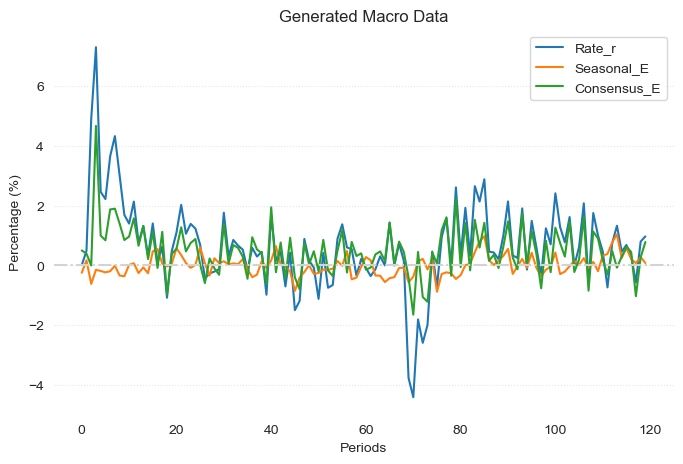

In [41]:
fig, ax = plt.subplots(figsize = (8, 5))
(df_macro_stationary[['Rate_r','Seasonal_E','Consensus_E']] * 100).plot(ax = ax)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
ax.yaxis.grid(True, ls = ':', alpha = 0.5) 
plt.axhline(0, ls = '-.', color = 'lightgray')
plt.title(r'Generated Macro Data')
plt.xlabel('Periods')
plt.ylabel(r'Percentage (%)')
plt.show()

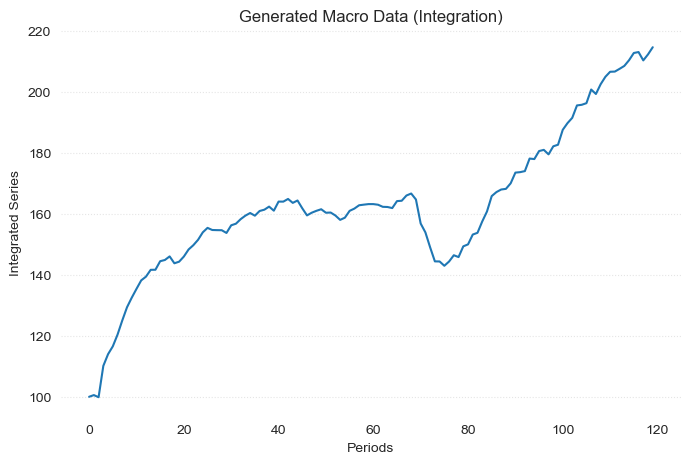

In [42]:
fig, ax = plt.subplots(figsize = (8, 5))
df_macro_stationary['I_hat'].plot()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
ax.yaxis.grid(True, ls = ':', alpha = 0.5) 

plt.title(r'Generated Macro Data (Integration)')
plt.xlabel('Periods')
plt.ylabel(r'Integrated Series')
plt.show()

In [51]:
fake_df = pd.DataFrame()

for i in range(100) :
    fake_df = pd.concat(
        [
            fake_df,
            simulate_macro_full_stationary(
                n=120, # 총 시계열 길이
                r0=0.0001, # 초기 수익률
                I0=100, # 초기 Macro 지표 수준 값
                mu_c=0.005, # 시장 건센서스의 장기 평균
                phi_c=-0.35, # 자기회귀 계수
                gamma=0.85, # 예측 오류에 대한 민감도
                sigma_c=0.005, # 컨센서스 변동성
                omega=1e-6, # GARCH의 기저 분산
                alpha=0.13, # GARCH 충격반응계수
                beta=0.67, # 과거 변동성의 지속 정도
                phi=[0.5], # AR(1) 충격 구조
                theta=[0.3], # MA(1) 충격 구조
                p_jump=0.002, # 점프 발생 확률
                jump_std=0.03, # 점프 충격의 표준 편차
                sarima_order=(1,0,0), # 계절적 시장 컨센서스의 AR구조
                sarima_seasonal=(1,0,0,12), # 계절적 시장 컨센서스의 계절구조
                seed=None,
                seasonal_phi = 0.3, 
                seasonal_Phi = 0.2, 
                sigma_season=0.00001,
            )['I_hat']
        ], axis = 1
    )

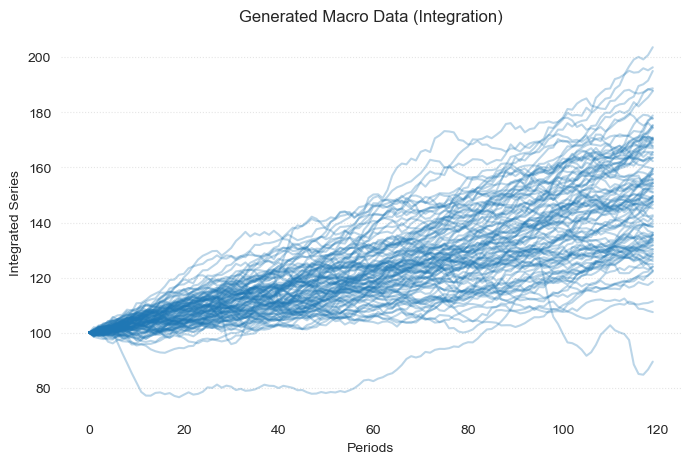

In [52]:
fig, ax = plt.subplots(figsize = (8, 5))
fake_df.plot(legend = False, color = 'tab:blue', alpha = 0.3, ax=ax)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
ax.yaxis.grid(True, ls = ':', alpha = 0.5) 

plt.title(r'Generated Macro Data (Integration)')
plt.xlabel('Periods')
plt.ylabel(r'Integrated Series')
plt.show()

이 시계열 생성 모델은 정적인 예측 모델에서 벗어나, 금융시장 참여자들의 반응 구조를 직접적으로 반영할 수 있는 시뮬레이션 환경을 구축하고자 하는 목적에서 출발하였다. 기존의 ARIMA나 GARCH 기반 시계열 모델은 과거의 반복 패턴이나 변동성을 추정하는 데에는 유용하지만, 전략 수립 관점에서 중요한 정책 이벤트, 정보 공개, 외생적 충격과 같은 요인에 대한 시장 반응을 반영하기에는 구조적으로 제한적이다.

본 모델은 수익률 시계열을 계절성, 기대 변화, 충격이라는 세 가지 요소로 분해하여, 전략 설계자나 리스크 매니저가 실제로 고려해야 하는 핵심 요인들을 개별적으로 다룰 수 있도록 구성되었다. 특히 기대를 과거 오차 기반으로 조정되는 학습 가능한 변수로 설정함으로써, 금리 발표나 경제 지표 서프라이즈 등 이벤트에 대한 시장의 선반영, 과잉반응, 점진적 조정 등을 시뮬레이션 레벨에서 재현할 수 있게 하였다.

이러한 구조는 단순한 시계열 복제가 아니라, 투자 전략이 실제 시장 환경에서 어떻게 작동할지를 테스트하는 실험 환경을 구성하는 데 유용하다. 예를 들어 특정 정책 충격이 발생했을 때 수익률의 회복 경로가 얼마나 빠른지, 기대 조정이 얼마나 지연되며 이에 따라 전략이 수익 기회를 얼마나 놓치는지를 모의 실험할 수 있다. 또한 전략 백테스트의 국면 민감도나 정책에 대한 민감도, 충격 이후의 리버설 구조 등이 실제로 작동하는지를 평가할 수 있는 데이터 환경을 제공한다.

이 모델은 GAN이나 Transformer 같은 머신러닝 기반 모델이 학습에 사용할 수 있는 현실적인 macro 시계열 데이터를 생성하는 데에도 활용 가능하며, 인과 구조를 반영한 전략 설계, 정책 시나리오 테스트, stress test 기반 자산 배분 모델 구축 등 다양한 목적에 응용될 수 있다.

물론 본 모델은 초기적 형태로, 파라미터 추정의 정교화, 다변량 확장, 충격 간 상호작용 구조의 모형화 등에서 추가적인 개선이 필요하다. 그럼에도 불구하고 기대, 계절성, 충격이라는 세 가지 요인을 구분해 금융시장 구조에 기반한 시계열을 설계하려는 시도는 실전 전략 생성과 테스트에 있어 의미 있는 출발점이 될 수 있다고 판단된다. 향후에는 causal model, knowledge graph 기반 네트워크 구조 등과의 결합을 통해 전략 시뮬레이션 도구로서의 기능을 더욱 확장해나갈 수 있을 것이다.